In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest, uniform

In [ ]:
def LCG(a, c, m, seed, N):
    X = np.zeros(N)
    X[0] = seed
    for i in range(1, N):
        X[i] = (a * X[i-1] + c) % m
    return X / m 

In [3]:
params = [
    {"a": 1664525, "c": 1013904223, "m": 2**32, "name": "Set A"},
    {"a": 1103515245, "c": 12345, "m": 2**31, "name": "Set B"}
]

N = 10_000
seed = 12345


--- Set A ---
Media: 0.4987
Varianza: 0.0830


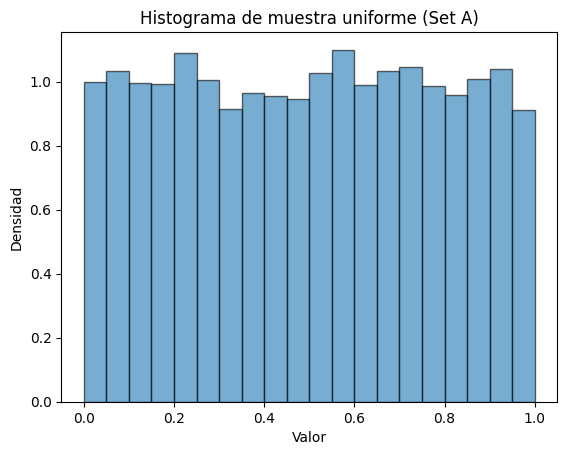

K-S estadístico = 0.0061, p-valor = 0.8540
No se rechaza H0: la muestra proviene de una distribución Uniform(0,1)

--- Set B ---
Media: 0.4989
Varianza: 0.0849


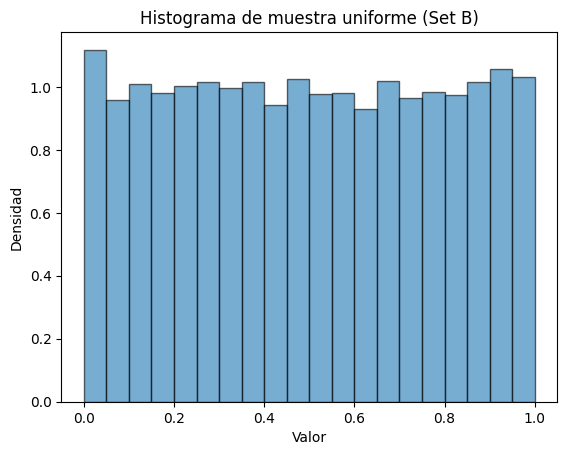

K-S estadístico = 0.0064, p-valor = 0.8066
No se rechaza H0: la muestra proviene de una distribución Uniform(0,1)


In [5]:
for p in params:
    U = LCG(p["a"], p["c"], p["m"], seed, N)

    print(f"\n--- {p['name']} ---")
    print(f"Media: {np.mean(U):.4f}")
    print(f"Varianza: {np.var(U):.4f}")

    plt.hist(U, bins=20, density=True, alpha=0.6, edgecolor='black')
    plt.title(f"Histograma de muestra uniforme ({p['name']})")
    plt.xlabel("Valor")
    plt.ylabel("Densidad")
    plt.show()

    stat, pval = kstest(U, 'uniform')
    print(f"K-S estadístico = {stat:.4f}, p-valor = {pval:.4f}")
    if pval > 0.05:
        print("No se rechaza H0: la muestra proviene de una distribución Uniform(0,1)")
    else:
        print("Se rechaza H0: la muestra no parece uniforme")

Los resultados obtenidos muestran que las muestras generadas presentan una media cercana a 0.5 y una varianza cercana a 0.0833, valores teóricos de una distribución uniforme. Los p-valores de la prueba de Kolmogorov–Smirnov 0.85 y 0.81 son altos, lo que indica que no se rechaza la hipótesis nula de uniformidad. Por lo tanto, se concluye que los números generados siguen una distribución Uniforme(0,1) y que ambos conjuntos de parámetros producen resultados consistentes y adecuados.